# Simon's Algorithm

Simon's algorithm solves a specific period-finding problem. It demonstrates an exponential speedup over any classical algorithm.

**The Problem:**
We are given a black-box function $f: \{0, 1\}^n \rightarrow \{0, 1\}^n$. 
We are promised that there exists a hidden, secret binary string $s$ such that:
$$f(x) = f(y) \iff x \oplus y = s \text{ (or if } x = y \text{)}$$

* If $s = 00\dots0$, the function is **1-to-1** (every input gives a unique output).
* If $s \neq 00\dots0$, the function is **2-to-1** (exactly two inputs map to every output, and they are separated by the XOR "period" $s$).

**The Goal:** Find the secret string $s$.
* **Classically:** We would have to guess and check inputs until we find a collision (two inputs that yield the same output). Because of the Birthday Paradox, this requires $O(2^{n/2})$ queries—an exponential amount of time.
* **Quantum:** Simon's algorithm requires only $O(n)$ queries to the quantum oracle to find enough information to solve for $s$ using classical linear algebra.

In [10]:
# Import necessary libraries
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Initialize the simulator
simulator = AerSimulator()

## Step 1: The Simon Oracle

Unlike the previous algorithms where the output was a single bit, Simon's function outputs an $n$-bit string. Therefore, our oracle requires two registers of size $n$:
1.  **Data Register:** $n$ qubits for the input $|x\rangle$.
2.  **Ancilla Register:** $n$ qubits to store the output $|f(x)\rangle$.

The oracle applies the unitary $U_f$:
$$|x\rangle|0\rangle \xrightarrow{U_f} |x\rangle|f(x)\rangle$$

To build a 2-to-1 oracle for a specific secret string $s$:
1.  Copy the input register to the output register using CNOT gates.
2.  Find the index of the first `1` in our secret string $s$.
3.  Use that index as a control qubit to XOR the rest of the $s$ string into the output register. This effectively overwrites some information, forcing the function to be 2-to-1 with the period $s$.

Simon's Oracle for s = '110':


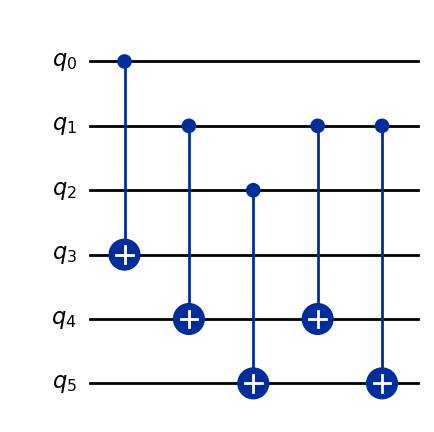

In [11]:
def simon_oracle(s):
    """
    Constructs a quantum oracle for Simon's algorithm given a secret string s.
    """
    n = len(s)
    # We need 2n qubits (n for input, n for output)
    qc = QuantumCircuit(n * 2)
    
    # Qiskit orders qubits from right-to-left. 
    # We reverse the string to make indexing intuitive (s[0] is qubit 0)
    s_rev = s[::-1]
    
    # 1. Copy the input register to the ancilla register
    for i in range(n):
        qc.cx(i, i + n)
        
    # 2. Create the 2-to-1 mapping based on s
    # Find the first index where the secret string is '1'
    j = s_rev.find('1')
    
    if j != -1: # If s is not all zeros
        for i in range(n):
            # If the bit is 1, apply a CNOT from the first '1' index to the ancilla
            if s_rev[i] == '1':
                qc.cx(j, i + n)
                
    qc.name = f"Simon Oracle (s={s})"
    return qc

# Let's visualize an oracle for n=3, s='110'
s_test = '110'
print(f"Simon's Oracle for s = '{s_test}':")
display(simon_oracle(s_test).draw('mpl'))

## Step 2: Simon's Quantum Circuit

The circuit is remarkably simple and looks very similar to Deutsch-Jozsa, but we only apply Hadamards to the input register, and we measure *only* the input register.

1.  Initialize $2n$ qubits to $|0\rangle$.
2.  Apply Hadamard gates to the first $n$ qubits (the data register) to create a superposition of all possible inputs.
3.  Apply the Oracle $U_f$. (This entangles the two registers).
4.  Apply Hadamard gates to the first $n$ qubits again. This creates interference that destructively cancels out any state that does not perfectly align with the secret string $s$.
5.  Measure the first $n$ qubits.

**The Math:**
The measurement will yield a bitstring $z$. The mathematics of the interference guarantees that the dot product of $z$ and our secret string $s$, modulo 2, will always equal zero:
$$z \cdot s \equiv 0 \pmod 2$$

Simon's Algorithm Circuit:


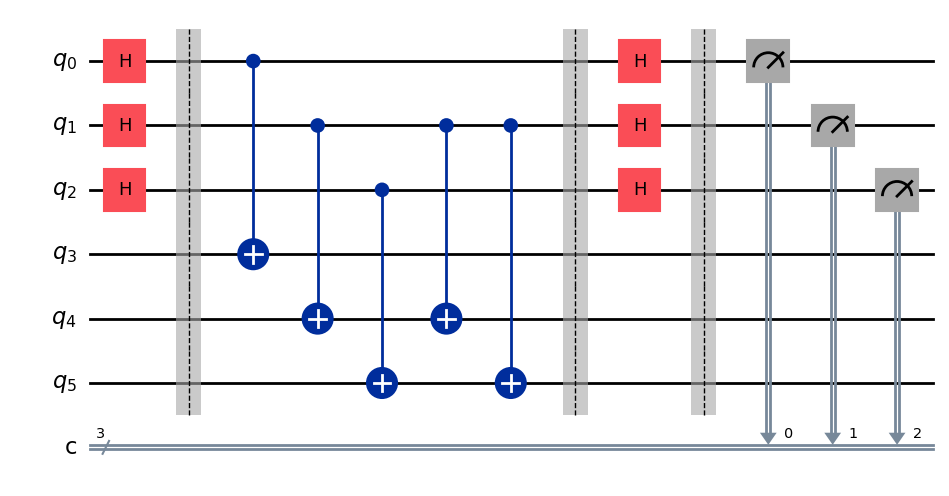

In [12]:
def simon_algorithm(oracle, n):
    """
    Constructs the full Simon's algorithm circuit.
    """
    # 2n qubits, n classical bits for measuring the top register
    qc = QuantumCircuit(n * 2, n)
    
    # 1. Superposition: Apply H-gates to the input register
    for qubit in range(n):
        qc.h(qubit)
    qc.barrier()
    
    # 2. Apply the Oracle
    qc.compose(oracle, inplace=True)
    qc.barrier()
    
    # 3. Interference: Apply H-gates to the input register
    for qubit in range(n):
        qc.h(qubit)
    qc.barrier()
    
    # 4. Measurement
    for i in range(n):
        qc.measure(i, i)
        
    return qc

# Visualize the full circuit
n = len(s_test)
test_oracle = simon_oracle(s_test)
simon_circuit = simon_algorithm(test_oracle, n)

print("Simon's Algorithm Circuit:")
display(simon_circuit.draw('mpl'))

## Step 3: Execution and Classical Solving

The quantum computer does not give us $s$ directly. Instead, it acts as a subroutine that hands us random equations. 

Every time we run the circuit, we get a string $z$ where $z \cdot s \equiv 0 \pmod 2$. 
If we run the circuit roughly $O(n)$ times, we will gather $n-1$ linearly independent equations. We can then use classical Gaussian elimination to solve the system of equations and find $s$.

Let's run the simulation and verify that every single measurement we get satisfies the rule $z \cdot s = 0 \pmod 2$.

Measurement outcomes for s = '110':


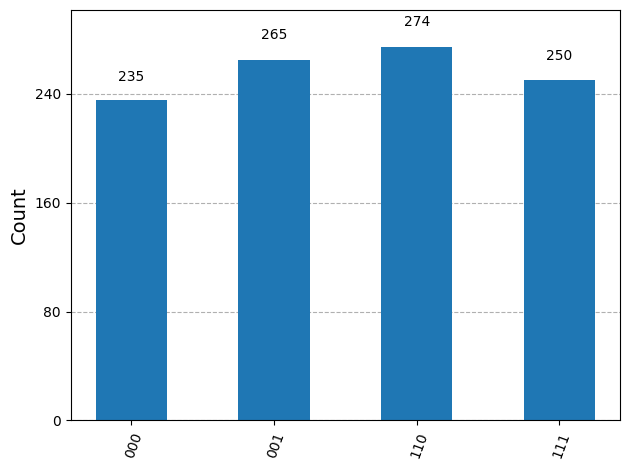


--- Classical Post-Processing Verification ---
Secret String s = 110

Measured z = 111 | z·s = (1*1 + 1*1 + 1*0) = 0 mod 2
Measured z = 001 | z·s = (0*1 + 0*1 + 1*0) = 0 mod 2
Measured z = 000 | z·s = (0*1 + 0*1 + 0*0) = 0 mod 2
Measured z = 110 | z·s = (1*1 + 1*1 + 0*0) = 0 mod 2

Because all dot products equal 0, a classical computer can now easily solve this system of equations to find s = 110!


In [13]:
# Define our secret string
secret_s = '110'
n = len(secret_s)

# Build and run the circuit
oracle = simon_oracle(secret_s)
circuit = simon_algorithm(oracle, n)

transpiled_circuit = transpile(circuit, simulator)
job = simulator.run(transpiled_circuit, shots=1024)
counts = job.result().get_counts()

# Plot the results
print(f"Measurement outcomes for s = '{secret_s}':")
display(plot_histogram(counts))

print("\n--- Classical Post-Processing Verification ---")
print(f"Secret String s = {secret_s}\n")

# Verify that z dot s = 0 mod 2 for all measured strings
for z in counts.keys():
    # Calculate the dot product modulo 2
    # zip() pairs up the bits of z and s
    dot_product = sum(int(z_i) * int(s_i) for z_i, s_i in zip(z, secret_s)) % 2
    
    print(f"Measured z = {z} | z·s = ({z[0]}*{secret_s[0]} + {z[1]}*{secret_s[1]} + {z[2]}*{secret_s[2]}) = {dot_product} mod 2")
    
print("\nBecause all dot products equal 0, a classical computer can now easily solve this system of equations to find s = 110!")